In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ID = "turkiye-border-wellbeing-2026"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")

Mounted at /content/drive
Earth Engine ready.


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

INTERIM = ROOT / "data/interim"
PROCESSED = ROOT / "data/processed"
RAW_GREENNESS = ROOT / "data/raw/ndvi"
FIGURES = ROOT / "figures/appendix"

RAW_GREENNESS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

grid_wgs84 = grid[
    ["grid_id", "geometry"]
].to_crs("EPSG:4326")

print("Grid cells:", len(grid_wgs84))

Grid cells: 19001


In [5]:
MODIS_ID = "MODIS/061/MOD13Q1"

modis = (
    ee.ImageCollection(MODIS_ID)
    .filterDate("2014-01-01", "2026-01-01")
)

print("MODIS images:",
      modis.size().getInfo())

MODIS images: 276


In [6]:
def clean_modis(image):

    qa = image.select("DetailedQA")

    # Bits 0-1: VI quality
    vi_quality = qa.bitwiseAnd(3)

    good_quality = vi_quality.eq(0)

    ndvi = (
        image.select("NDVI")
        .multiply(0.0001)
        .updateMask(good_quality)
        .rename("NDVI")
    )

    evi = (
        image.select("EVI")
        .multiply(0.0001)
        .updateMask(good_quality)
        .rename("EVI")
    )

    return (
        ndvi.addBands(evi)
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )

modis_clean = modis.map(clean_modis)

print("Clean MODIS collection created.")

Clean MODIS collection created.


In [7]:
def annual_greenness(year):

    year = int(year)

    annual = (
        modis_clean
        .filterDate(
            f"{year}-01-01",
            f"{year + 1}-01-01"
        )
        .mean()
        .rename(
            f"ndvi_{year}",
            f"evi_{year}"
        )
    )

    return annual

In [8]:
annual_images = []

for year in range(2014, 2026):
    annual_images.append(
        annual_greenness(year)
    )

greenness_stack = ee.Image.cat(
    annual_images
)

print(
    greenness_stack.bandNames().getInfo()
)

['ndvi_2014', 'evi_2014', 'ndvi_2015', 'evi_2015', 'ndvi_2016', 'evi_2016', 'ndvi_2017', 'evi_2017', 'ndvi_2018', 'evi_2018', 'ndvi_2019', 'evi_2019', 'ndvi_2020', 'evi_2020', 'ndvi_2021', 'evi_2021', 'ndvi_2022', 'evi_2022', 'ndvi_2023', 'evi_2023', 'ndvi_2024', 'evi_2024', 'ndvi_2025', 'evi_2025']


In [9]:
BATCH_SIZE = 500

test_batch = (
    grid_wgs84
    .iloc[:BATCH_SIZE]
    [["grid_id", "geometry"]]
    .copy()
)

test_ee = geemap.geopandas_to_ee(
    test_batch
)

print(
    "Test EE features:",
    test_ee.size().getInfo()
)

Test EE features: 500


In [10]:
test_stats = greenness_stack.reduceRegions(
    collection=test_ee,
    reducer=ee.Reducer.mean(),
    scale=250,
    tileScale=4
)

test_df = geemap.ee_to_df(
    test_stats
)

print("Shape:", test_df.shape)
print(test_df.columns.tolist())
test_df.head()

Shape: (500, 25)
['evi_2014', 'evi_2015', 'evi_2016', 'evi_2017', 'evi_2018', 'evi_2019', 'evi_2020', 'evi_2021', 'evi_2022', 'evi_2023', 'evi_2024', 'evi_2025', 'grid_id', 'ndvi_2014', 'ndvi_2015', 'ndvi_2016', 'ndvi_2017', 'ndvi_2018', 'ndvi_2019', 'ndvi_2020', 'ndvi_2021', 'ndvi_2022', 'ndvi_2023', 'ndvi_2024', 'ndvi_2025']


,evi_2014,evi_2015,evi_2016,evi_2017,evi_2018,evi_2019,evi_2020,evi_2021,evi_2022,evi_2023,...,ndvi_2016,ndvi_2017,ndvi_2018,ndvi_2019,ndvi_2020,ndvi_2021,ndvi_2022,ndvi_2023,ndvi_2024,ndvi_2025
0,0.220640,0.230362,0.242993,0.223626,0.250600,0.214293,0.225625,0.190208,0.165876,0.175723,...,0.528978,0.492525,0.523254,0.502395,0.512720,0.428537,0.407861,0.414941,0.441658,0.361687
1,0.251269,0.258200,0.252986,0.220513,0.239226,0.218707,0.237144,0.206969,0.188679,0.212698,...,0.553778,0.528369,0.525947,0.530179,0.575341,0.489137,0.475522,0.517118,0.489444,0.425777
2,0.025237,0.031900,0.029995,0.024777,0.021637,0.019146,0.014438,0.017703,0.034373,0.026499,...,0.077310,0.058664,0.047771,0.041680,0.029809,0.031913,0.083594,0.071122,0.047042,0.057428
3,0.065472,0.061488,0.067144,0.064127,0.058890,0.056432,0.058645,0.054752,0.061502,0.059543,...,0.210465,0.192781,0.167411,0.165999,0.176250,0.154167,0.176298,0.192386,0.117957,0.132473
4,0.224657,0.254912,0.248226,0.219786,0.245972,0.199607,0.238663,0.190751,0.166931,0.188587,...,0.515688,0.494555,0.498670,0.497584,0.523286,0.442423,0.411527,0.454275,0.451898,0.396898


In [11]:
all_batches = []

for start in range(
    0,
    len(grid_wgs84),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(grid_wgs84)
    )

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(
        batch_gdf
    )

    batch_stats = greenness_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.mean(),
        scale=250,
        tileScale=4
    )

    batch_df = geemap.ee_to_df(
        batch_stats
    )

    all_batches.append(
        batch_df
    )

print("All batches completed.")

Processing grids 0–500 of 19,001
Processing grids 500–1,000 of 19,001
Processing grids 1,000–1,500 of 19,001
Processing grids 1,500–2,000 of 19,001
Processing grids 2,000–2,500 of 19,001
Processing grids 2,500–3,000 of 19,001
Processing grids 3,000–3,500 of 19,001
Processing grids 3,500–4,000 of 19,001
Processing grids 4,000–4,500 of 19,001
Processing grids 4,500–5,000 of 19,001
Processing grids 5,000–5,500 of 19,001
Processing grids 5,500–6,000 of 19,001
Processing grids 6,000–6,500 of 19,001
Processing grids 6,500–7,000 of 19,001
Processing grids 7,000–7,500 of 19,001
Processing grids 7,500–8,000 of 19,001
Processing grids 8,000–8,500 of 19,001
Processing grids 8,500–9,000 of 19,001
Processing grids 9,000–9,500 of 19,001
Processing grids 9,500–10,000 of 19,001
Processing grids 10,000–10,500 of 19,001
Processing grids 10,500–11,000 of 19,001
Processing grids 11,000–11,500 of 19,001
Processing grids 11,500–12,000 of 19,001
Processing grids 12,000–12,500 of 19,001
Processing grids 12,50

In [12]:
greenness_wide = pd.concat(
    all_batches,
    ignore_index=True
)

print("Rows:",
      len(greenness_wide))

print("Columns:",
      len(greenness_wide.columns))

print(
    "Unique grid IDs:",
    greenness_wide["grid_id"].nunique()
)

Rows: 19001
Columns: 25
Unique grid IDs: 19001


In [13]:
ndvi_cols = [
    f"ndvi_{year}"
    for year in range(2014, 2026)
]

evi_cols = [
    f"evi_{year}"
    for year in range(2014, 2026)
]

ndvi_long = greenness_wide[
    ["grid_id"] + ndvi_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="ndvi"
)

ndvi_long["year"] = (
    ndvi_long["year"]
    .str.replace("ndvi_", "", regex=False)
    .astype(int)
)

evi_long = greenness_wide[
    ["grid_id"] + evi_cols
].melt(
    id_vars="grid_id",
    var_name="year",
    value_name="evi"
)

evi_long["year"] = (
    evi_long["year"]
    .str.replace("evi_", "", regex=False)
    .astype(int)
)

greenness_panel = ndvi_long.merge(
    evi_long,
    on=["grid_id", "year"],
    how="left"
)

greenness_panel = (
    greenness_panel
    .sort_values(["grid_id", "year"])
    .reset_index(drop=True)
)

print(
    "Panel observations:",
    len(greenness_panel)
)

greenness_panel.head(15)

Panel observations: 228012


,grid_id,year,ndvi,evi
0,G000001,2014,0.481539,0.220640
1,G000001,2015,0.461773,0.230362
2,G000001,2016,0.528978,0.242993
3,G000001,2017,0.492525,0.223626
4,G000001,2018,0.523254,0.250600
5,G000001,2019,0.502395,0.214293
6,G000001,2020,0.512720,0.225625
7,G000001,2021,0.428537,0.190208
8,G000001,2022,0.407861,0.165876
9,G000001,2023,0.414941,0.175723


In [14]:
print(
    greenness_panel[
        ["ndvi", "evi"]
    ].describe()
)

print(
    "Missing NDVI:",
    greenness_panel["ndvi"]
    .isna()
    .sum()
)

print(
    "Missing EVI:",
    greenness_panel["evi"]
    .isna()
    .sum()
)

                ndvi            evi
count  228012.000000  228012.000000
mean        0.508015       0.312459
std         0.106713       0.068177
min        -0.123173      -0.028511
25%         0.437956       0.269761
50%         0.474705       0.295717
75%         0.554000       0.338442
max         0.816811       0.605480
Missing NDVI: 0
Missing EVI: 0


In [15]:
greenness_qc = (
    greenness_panel
    .groupby("year")
    .agg(
        ndvi_count=("ndvi", "count"),
        ndvi_mean=("ndvi", "mean"),
        ndvi_median=("ndvi", "median"),
        ndvi_min=("ndvi", "min"),
        ndvi_max=("ndvi", "max"),
        evi_count=("evi", "count"),
        evi_mean=("evi", "mean"),
        evi_median=("evi", "median"),
        evi_min=("evi", "min"),
        evi_max=("evi", "max")
    )
)

print(greenness_qc)

      ndvi_count  ndvi_mean  ndvi_median  ndvi_min  ndvi_max  evi_count  \
year                                                                      
2014       19001   0.542678     0.511756 -0.081003  0.809170      19001   
2015       19001   0.497463     0.458630 -0.091410  0.805029      19001   
2016       19001   0.500811     0.458950 -0.076159  0.799336      19001   
2017       19001   0.515262     0.476476 -0.060082  0.816811      19001   
2018       19001   0.524895     0.492536 -0.095693  0.783971      19001   
2019       19001   0.503509     0.468795 -0.116071  0.790572      19001   
2020       19001   0.512569     0.481260 -0.102836  0.794962      19001   
2021       19001   0.521671     0.494930 -0.111466  0.794116      19001   
2022       19001   0.492004     0.453364 -0.123173  0.788211      19001   
2023       19001   0.492316     0.456314 -0.113592  0.788284      19001   
2024       19001   0.488552     0.444121 -0.099717  0.778174      19001   
2025       19001   0.5044

In [16]:
greenness_panel_path = (
    PROCESSED /
    "greenness_grid_year_2014_2025.csv"
)

greenness_panel.to_csv(
    greenness_panel_path,
    index=False
)

print("Saved:", greenness_panel_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/processed/greenness_grid_year_2014_2025.csv


In [17]:
greenness_wide_path = (
    INTERIM /
    "greenness_grid_annual_wide_2014_2025.csv"
)

greenness_wide.to_csv(
    greenness_wide_path,
    index=False
)

print("Saved:", greenness_wide_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/greenness_grid_annual_wide_2014_2025.csv


In [18]:
greenness_qc_path = (
    INTERIM /
    "greenness_annual_qc_2014_2025.csv"
)

greenness_qc.to_csv(
    greenness_qc_path,
    index_label="year"
)

print("Saved:", greenness_qc_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/greenness_annual_qc_2014_2025.csv


In [19]:
import json

greenness_metadata = {
    "dataset": "MODIS/061/MOD13Q1",
    "period": "2014-2025",
    "temporal_resolution_source": "16-day",
    "spatial_resolution_source": "250 m",
    "grid_resolution": "1 km x 1 km",
    "variables": [
        "NDVI",
        "EVI"
    ],
    "scale_factor": 0.0001,
    "quality_filter": "DetailedQA bits 0-1 equal to 0",
    "annual_aggregation": "Mean of valid 16-day observations",
    "grid_count": 19001,
    "panel_observations": 228012
}

metadata_path = (
    INTERIM /
    "greenness_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        greenness_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", metadata_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/greenness_metadata.json


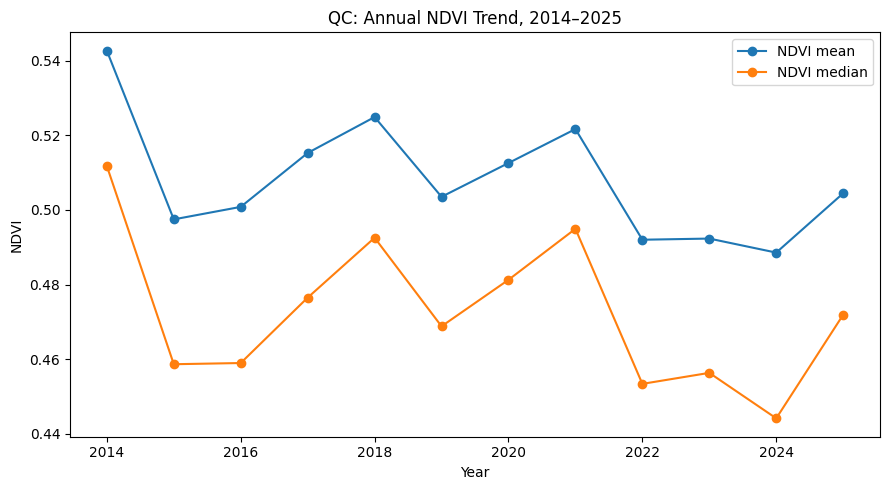

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_ndvi_annual_trend.png


In [20]:
import matplotlib.pyplot as plt

annual_green = (
    greenness_panel
    .groupby("year")
    .agg(
        ndvi_mean=("ndvi", "mean"),
        ndvi_median=("ndvi", "median"),
        evi_mean=("evi", "mean"),
        evi_median=("evi", "median")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_green["year"],
    annual_green["ndvi_mean"],
    marker="o",
    label="NDVI mean"
)

ax.plot(
    annual_green["year"],
    annual_green["ndvi_median"],
    marker="o",
    label="NDVI median"
)

ax.set_xlabel("Year")
ax.set_ylabel("NDVI")
ax.set_title("QC: Annual NDVI Trend, 2014–2025")
ax.legend()

plt.tight_layout()

out = (
    FIGURES /
    "qc_ndvi_annual_trend.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)

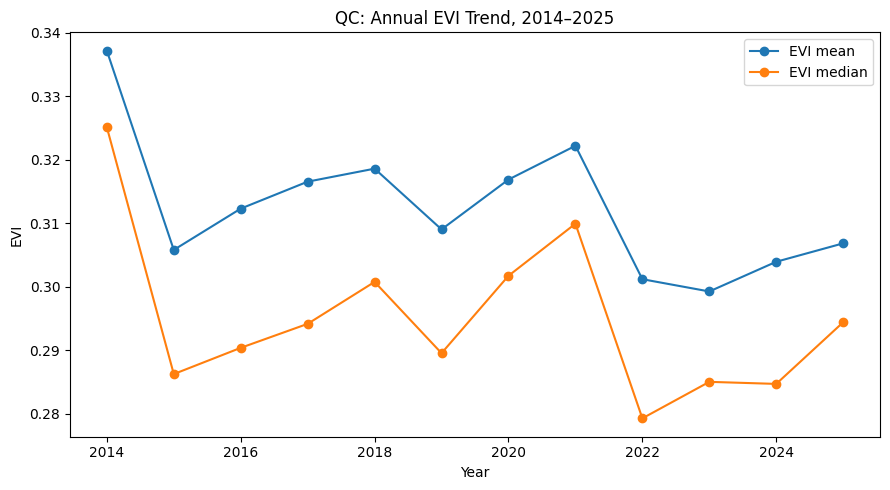

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_evi_annual_trend.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_green["year"],
    annual_green["evi_mean"],
    marker="o",
    label="EVI mean"
)

ax.plot(
    annual_green["year"],
    annual_green["evi_median"],
    marker="o",
    label="EVI median"
)

ax.set_xlabel("Year")
ax.set_ylabel("EVI")
ax.set_title("QC: Annual EVI Trend, 2014–2025")
ax.legend()

plt.tight_layout()

out = (
    FIGURES /
    "qc_evi_annual_trend.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)